In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [ ]:
data_set=pd.read_csv('/content/StudentPerformanceFactors.csv')

In [ ]:
data_set.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [59]:
data_set.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 28 columns):
 #   Column                                 Non-Null Count  Dtype
---  ------                                 --------------  -----
 0   Hours_Studied                          6607 non-null   int64
 1   Attendance                             6607 non-null   int64
 2   Sleep_Hours                            6607 non-null   int64
 3   Previous_Scores                        6607 non-null   int64
 4   Tutoring_Sessions                      6607 non-null   int64
 5   Physical_Activity                      6607 non-null   int64
 6   Exam_Score                             6607 non-null   int64
 7   Parental_Involvement_Low               6607 non-null   bool 
 8   Parental_Involvement_Medium            6607 non-null   bool 
 9   Access_to_Resources_Low                6607 non-null   bool 
 10  Access_to_Resources_Medium             6607 non-null   bool 
 11  Extracurricular_Activities_Yes

In [46]:
data_set = pd.get_dummies(data_set, drop_first=True)

In [57]:
nanValues=data_set.isnull().sum()
nanValues[nanValues>0]

,0


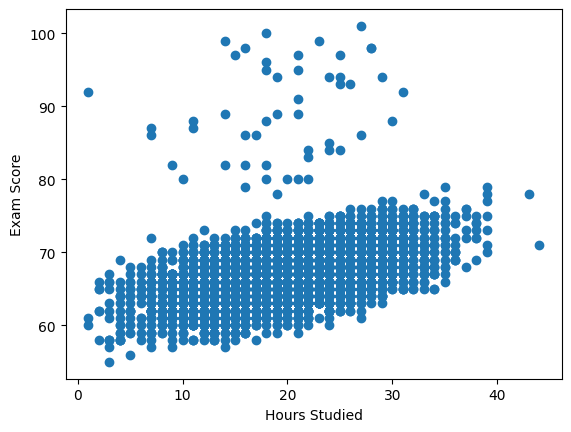

In [49]:
plt.scatter(data_set['Hours_Studied'],data_set['Exam_Score'])
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

In [50]:
x=data_set.drop("Exam_Score",axis=1)
y=data_set['Exam_Score']

In [51]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [52]:
model = LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [53]:
y_pred=model.predict(x_test)

In [54]:
r2 = r2_score(y_test, y_pred)
print(r2)

mae = mean_absolute_error(y_test, y_pred)
print(mae)

0.7696017567194432
0.45028541547009376


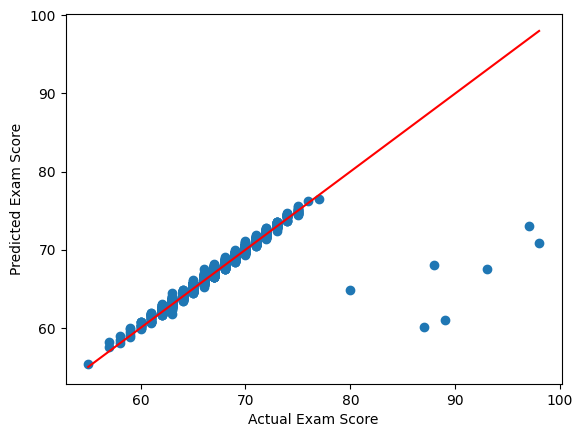

In [55]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],'r')
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.show()
